In [1]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Charger le CSV
df = pd.read_csv("../data/dataset_selection.csv")

# Aperçu du dataset
print("Aperçu du dataset :")
print(df.head())

print(f"\nNombre total d'images : {len(df)}")

# Répartition des labels
class_counts = df['label'].value_counts()
print("\nRépartition des labels :")
print(class_counts)

Aperçu du dataset :
                                                path     label
0  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
1  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
2  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tes...  glaucome
3  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
4  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome

Nombre total d'images : 7796

Répartition des labels :
label
glaucome    1949
mda         1949
diabete     1949
normaux     1949
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df,
    test_size=0.1,
    stratify=df['label'],
    random_state=42
)

print("Tailles des splits :")
print(f"Train : {len(df_train)}")
print(f"Test : {len(df_test)}")

# Mapping label -> id
classes = sorted(df['label'].unique().tolist())
label_to_id = {c: i for i, c in enumerate(classes)}
print(f"\nClasses : {classes}")

Tailles des splits :
Train : 7016
Test : 780

Classes : ['diabete', 'glaucome', 'mda', 'normaux']


In [3]:
# Fonction pour enlever les bords noirs
def crop_black_border(img, thr=10, pad=10):
    """
    img: numpy array BGR ou grayscale
    thr: seuil (0-255)
    pad: marge ajoutée autour du crop
    """
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    
    mask = gray > thr
    if not mask.any():
        return img
    
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(img.shape[0] - 1, y1 + pad)
    x1 = min(img.shape[1] - 1, x1 + pad)
    
    return img[y0:y1+1, x0:x1+1]

# Fonction pour charger et prétraiter une image
def load_image(path, size=(128, 128)):
    """Charge une image, enlève les bords noirs et redimensionne"""
    img = cv2.imread(path)
    if img is None:
        return None
    img = crop_black_border(img, thr=10, pad=10)
    img = cv2.resize(img, size)
    return img

def augment_image(img):
    aug = []
    h, w = img.shape[:2]
    for angle in [-15, 15]:
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
        aug.append(cv2.warpAffine(img, M, (w, h)))
    aug.append(cv2.flip(img, 1))   # flip horizontal
    aug.append(cv2.flip(img, 0))   # flip vertical
    aug.append(np.clip(img.astype(np.float32) * 1.2 - 15, 0, 255).astype(np.uint8))
    return aug

print("Fonctions de prétraitement définies ✓")

Fonctions de prétraitement définies ✓


In [4]:
from skimage.feature import hog

def extract_hog_features(img):
    """Extrait les features HOG d'une image BGR"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True
    )
    return features

def extract_pixel_features(img):
    """Extrait les pixels aplatis (pour PCA)"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray.flatten().astype(np.float32) / 255.0

print("Fonctions d'extraction de features définies ✓")
print(f"HOG sur image 128x128 donne {extract_hog_features(np.zeros((128, 128, 3), dtype=np.uint8)).shape[0]} features")
print(f"Pixels aplatis sur image 128x128 donne {128*128} features")

Fonctions d'extraction de features définies ✓
HOG sur image 128x128 donne 8100 features
Pixels aplatis sur image 128x128 donne 16384 features


In [5]:
# Extraire les features de toutes les images
def extract_all_features(df_subset, extract_func, augment=False):
    """Extrait les features pour un dataframe donné"""
    features = []
    labels = []
    valid_indices = []
    
    for idx, row in tqdm(df_subset.iterrows(), total=len(df_subset)):
        img = load_image(row['path'])
        if img is None:
            continue
        
        features.append(extract_func(img))
        labels.append(label_to_id[row['label']])
        valid_indices.append(idx)
        if augment:
            for aug_img in augment_image(img):
                features.append(extract_func(aug_img))
                labels.append(label_to_id[row['label']])
                valid_indices.append(idx)
    
    return np.array(features), np.array(labels), valid_indices

print("Extraction des features pixels (pour PCA)...")
X_train_pixels, y_train, _ = extract_all_features(df_train, extract_pixel_features, augment=True)
X_test_pixels, y_test, _ = extract_all_features(df_test, extract_pixel_features)

print(f"\nShape X_train_pixels: {X_train_pixels.shape}")
print(f"Shape X_test_pixels: {X_test_pixels.shape}")

Extraction des features pixels (pour PCA)...


  0%|          | 5/7016 [00:00<05:35, 20.90it/s][ WARN:0@2.182] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@2.182] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  2%|▏         | 158/7016 [00:09<07:27, 15.34it/s][ WARN:0@11.669] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@11.669] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  5%|▌         | 358/7016 [00:25<1:29:45,  1.24it/s][ WARN:0@29.316] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@29.316] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
 11%|█         | 757/7016 [00:45<1:00:02,  1.74it/s][ WARN:0@47.938] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDire


Shape X_train_pixels: (42096, 16384)
Shape X_test_pixels: (780, 16384)


In [6]:
print("Extraction des features HOG...")
X_train_hog, _, _ = extract_all_features(df_train, extract_hog_features, augment=True)
X_test_hog, _, _ = extract_all_features(df_test, extract_hog_features)

print(f"\nShape X_train_hog: {X_train_hog.shape}")
print(f"Shape X_test_hog: {X_test_hog.shape}")

Extraction des features HOG...


  0%|          | 6/7016 [00:00<07:14, 16.14it/s][ WARN:0@447.075] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@447.075] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  2%|▏         | 161/7016 [00:10<05:02, 22.69it/s][ WARN:0@458.954] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@458.954] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  6%|▋         | 455/7016 [00:30<07:32, 14.50it/s][ WARN:0@480.286] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@480.286] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
 11%|█         | 758/7016 [00:56<1:20:26,  1.30it/s][ WARN:0@505.948] global grfmt_tiff.cpp:122 TIFF_Warning TIFFR


Shape X_train_hog: (42096, 8100)
Shape X_test_hog: (780, 8100)


In [7]:
import gc
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler_pixels = StandardScaler()
X_train_pixels_scaled = scaler_pixels.fit_transform(X_train_pixels).astype('float32')
X_test_pixels_scaled  = scaler_pixels.transform(X_test_pixels).astype('float32')

del X_train_pixels, X_test_pixels
gc.collect()

print(f"Shape X_train_pixels_scaled: {X_train_pixels_scaled.shape}  dtype: {X_train_pixels_scaled.dtype}")
print(f"RAM estimée: {X_train_pixels_scaled.nbytes / 1e9:.2f} GB")
print("PCA sera testée avec différents n_components dans le GridSearch")

Shape X_train_pixels_scaled: (42096, 16384)  dtype: float32
RAM estimée: 2.76 GB
PCA sera testée avec différents n_components dans le GridSearch


In [8]:
scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog).astype('float32')
X_test_hog_scaled  = scaler_hog.transform(X_test_hog).astype('float32')

del X_train_hog, X_test_hog
gc.collect()

n_pixel_features = X_train_pixels_scaled.shape[1]
n_hog_features   = X_train_hog_scaled.shape[1]

total_gb = (X_train_pixels_scaled.nbytes + X_train_hog_scaled.nbytes) / 1e9
print(f"Shape X_train_hog_scaled: {X_train_hog_scaled.shape}  dtype: {X_train_hog_scaled.dtype}")
print(f"n_pixel_features: {n_pixel_features}  |  n_hog_features: {n_hog_features}")
print(f"RAM features (float32): {total_gb:.2f} GB — X_train_combined_raw créé à la demande")

Shape X_train_hog_scaled: (42096, 8100)  dtype: float32
n_pixel_features: 16384  |  n_hog_features: 8100
RAM features (float32): 4.12 GB — X_train_combined_raw créé à la demande


In [9]:
try:
    from cuml.ensemble import RandomForestClassifier as _CumlRF
    from sklearn.base import BaseEstimator, ClassifierMixin

    class CumlRFClassifier(BaseEstimator, ClassifierMixin):
        """Wrapper sklearn-compatible autour de cuML RF (corrige __sklearn_tags__ manquant)."""
        def __init__(self, n_estimators=100, max_depth=16, min_samples_split=2,
                     min_samples_leaf=1, max_features='sqrt', n_bins=64,
                     n_streams=1, random_state=None):
            self.n_estimators = n_estimators
            self.max_depth = max_depth
            self.min_samples_split = min_samples_split
            self.min_samples_leaf = min_samples_leaf
            self.max_features = max_features
            self.n_bins = n_bins
            self.n_streams = n_streams
            self.random_state = random_state

        def fit(self, X, y):
            self._estimator = _CumlRF(
                n_estimators=self.n_estimators,
                max_depth=self.max_depth if self.max_depth is not None else -1,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                max_features=self.max_features,
                n_bins=self.n_bins,
                n_streams=self.n_streams,
                random_state=self.random_state
            )
            self._estimator.fit(X.astype('float32'), y.astype('int32'))
            self.classes_ = np.unique(y)
            return self

        def predict(self, X):
            return np.array(self._estimator.predict(X.astype('float32'))).astype(int)

        def predict_proba(self, X):
            return np.array(self._estimator.predict_proba(X.astype('float32')))

    RandomForestClassifier = CumlRFClassifier
    USE_GPU_RF = True
    print("GPU: cuML RandomForestClassifier (wrapper sklearn-compatible)")
    y_train = y_train.astype('int32')
    y_test = y_test.astype('int32')

except ImportError:
    from sklearn.ensemble import RandomForestClassifier
    USE_GPU_RF = False
    print("CPU: sklearn RandomForestClassifier")

import gc
import ctypes
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

def _to_float32(X):
    return X.astype('float32')

to_float32 = FunctionTransformer(_to_float32)

print("Prêt pour l'entraînement.")

GPU: cuML RandomForestClassifier (wrapper sklearn-compatible)
Prêt pour l'entraînement.


In [10]:
results = {}

print("="*60)
print("Entraînement PCA")
print("="*60)

PCA_N_COMPONENTS = 100
RF_PARAMS = dict(n_estimators=300, max_depth=30, min_samples_split=2,
                 min_samples_leaf=1, max_features='sqrt', random_state=42)

if USE_GPU_RF:
    pipe_pca = Pipeline([
        ('pca', PCA(n_components=PCA_N_COMPONENTS, random_state=42)),
        ('to_float32', to_float32),
        ('rf', RandomForestClassifier(**RF_PARAMS, n_bins=64, n_streams=1))
    ])
else:
    pipe_pca = Pipeline([
        ('pca', PCA(n_components=PCA_N_COMPONENTS, random_state=42)),
        ('rf', RandomForestClassifier(**RF_PARAMS, n_jobs=-1))
    ])

pipe_pca.fit(X_train_pixels_scaled, y_train)
print(f"Entraînement PCA terminé ✓  (n_components={PCA_N_COMPONENTS})")

results['PCA'] = {
    'best_model': pipe_pca,
    'best_params': {'pca__n_components': PCA_N_COMPONENTS, **{f'rf__{k}': v for k, v in RF_PARAMS.items()}},
    'X_test': X_test_pixels_scaled
}

gc.collect()
ctypes.CDLL("libc.so.6").malloc_trim(0)

Entraînement PCA
Entraînement PCA terminé ✓  (n_components=100)


1

In [11]:
print("="*60)
print("Entraînement HOG")
print("="*60)

RF_PARAMS_HOG = dict(n_estimators=300, max_depth=30, min_samples_split=2,
                     min_samples_leaf=1, max_features='sqrt', random_state=42)

if USE_GPU_RF:
    rf_hog = RandomForestClassifier(**RF_PARAMS_HOG, n_bins=64, n_streams=1)
else:
    rf_hog = RandomForestClassifier(**RF_PARAMS_HOG, n_jobs=-1)

rf_hog.fit(X_train_hog_scaled, y_train)
print("Entraînement HOG terminé ✓")

results['HOG'] = {
    'best_model': rf_hog,
    'best_params': RF_PARAMS_HOG,
    'X_test': X_test_hog_scaled
}

gc.collect()
ctypes.CDLL("libc.so.6").malloc_trim(0)

Entraînement HOG
Entraînement HOG terminé ✓


1

In [12]:
print("="*60)
print("Entraînement PCA + HOG")
print("="*60)

pixel_cols = list(range(n_pixel_features))
hog_cols = list(range(n_pixel_features, n_pixel_features + n_hog_features))

X_train_combined_raw = np.hstack([X_train_pixels_scaled, X_train_hog_scaled])
X_test_combined_raw  = np.hstack([X_test_pixels_scaled,  X_test_hog_scaled])
print(f"X_train_combined_raw créé: {X_train_combined_raw.shape}  ({X_train_combined_raw.nbytes/1e9:.2f} GB)")

PCA_N_COMBINED = 100
RF_PARAMS_COMBINED = dict(n_estimators=300, max_depth=30, min_samples_split=2,
                          min_samples_leaf=1, max_features='sqrt', random_state=42)

if USE_GPU_RF:
    pipe_combined = Pipeline([
        ('features', ColumnTransformer([
            ('pca', PCA(n_components=PCA_N_COMBINED, random_state=42), pixel_cols),
            ('hog', 'passthrough', hog_cols)
        ])),
        ('to_float32', to_float32),
        ('rf', RandomForestClassifier(**RF_PARAMS_COMBINED, n_bins=64, n_streams=1))
    ])
else:
    pipe_combined = Pipeline([
        ('features', ColumnTransformer([
            ('pca', PCA(n_components=PCA_N_COMBINED, random_state=42), pixel_cols),
            ('hog', 'passthrough', hog_cols)
        ])),
        ('rf', RandomForestClassifier(**RF_PARAMS_COMBINED, n_jobs=-1))
    ])

pipe_combined.fit(X_train_combined_raw, y_train)

del X_train_combined_raw
gc.collect()
ctypes.CDLL("libc.so.6").malloc_trim(0)
print("Entraînement PCA+HOG terminé ✓  (X_train_combined_raw supprimé)")

results['PCA + HOG'] = {
    'best_model': pipe_combined,
    'best_params': {'features__pca__n_components': PCA_N_COMBINED,
                    **{f'rf__{k}': v for k, v in RF_PARAMS_COMBINED.items()}},
    'X_test': X_test_combined_raw
}

Entraînement PCA + HOG
X_train_combined_raw créé: (42096, 24484)  (4.12 GB)
Entraînement PCA+HOG terminé ✓  (X_train_combined_raw supprimé)


In [13]:
print("\n" + "="*70)
print("ÉVALUATION SUR LE JEU DE TEST")
print("="*70)

comparison_data = []

for name, data in results.items():
    model = data['best_model']
    X_test_loc = data['X_test']
    y_pred = np.array(model.predict(X_test_loc)).astype(int)

    acc  = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)

    results[name]['test_accuracy'] = acc
    results[name]['test_balanced_accuracy'] = bacc
    results[name]['test_f1'] = f1
    results[name]['y_pred'] = y_pred

    comparison_data.append({
        'Approche': name,
        'Test Accuracy': acc,
        'Balanced Acc': bacc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })

    print(f"\n--- {name} ---")
    print(f"Paramètres: {data['best_params']}")
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Balanced Accuracy: {bacc:.4f}")
    print(f"F1 Score (macro): {f1:.4f}")

comparison_df = pd.DataFrame(comparison_data).round(4)

print("\n" + "="*70)
print("TABLEAU COMPARATIF DES 3 APPROCHES")
print("="*70)
print(comparison_df.to_string(index=False))

best_approach = comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Approche']
print(f"\nMeilleure approche: {best_approach}")


ÉVALUATION SUR LE JEU DE TEST



--- PCA ---
Paramètres: {'pca__n_components': 100, 'rf__n_estimators': 300, 'rf__max_depth': 30, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_features': 'sqrt', 'rf__random_state': 42}
Test Accuracy: 0.7872
Balanced Accuracy: 0.7872
F1 Score (macro): 0.7703

--- HOG ---
Paramètres: {'n_estimators': 300, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'random_state': 42}
Test Accuracy: 0.7859
Balanced Accuracy: 0.7859
F1 Score (macro): 0.7565

--- PCA + HOG ---
Paramètres: {'features__pca__n_components': 100, 'rf__n_estimators': 300, 'rf__max_depth': 30, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_features': 'sqrt', 'rf__random_state': 42}
Test Accuracy: 0.7872
Balanced Accuracy: 0.7872
F1 Score (macro): 0.7580

TABLEAU COMPARATIF DES 3 APPROCHES
 Approche  Test Accuracy  Balanced Acc  Precision  Recall  F1 Score
      PCA         0.7872        0.7872     0.7883  0.7872    0.7703
      HOG         0.7859    

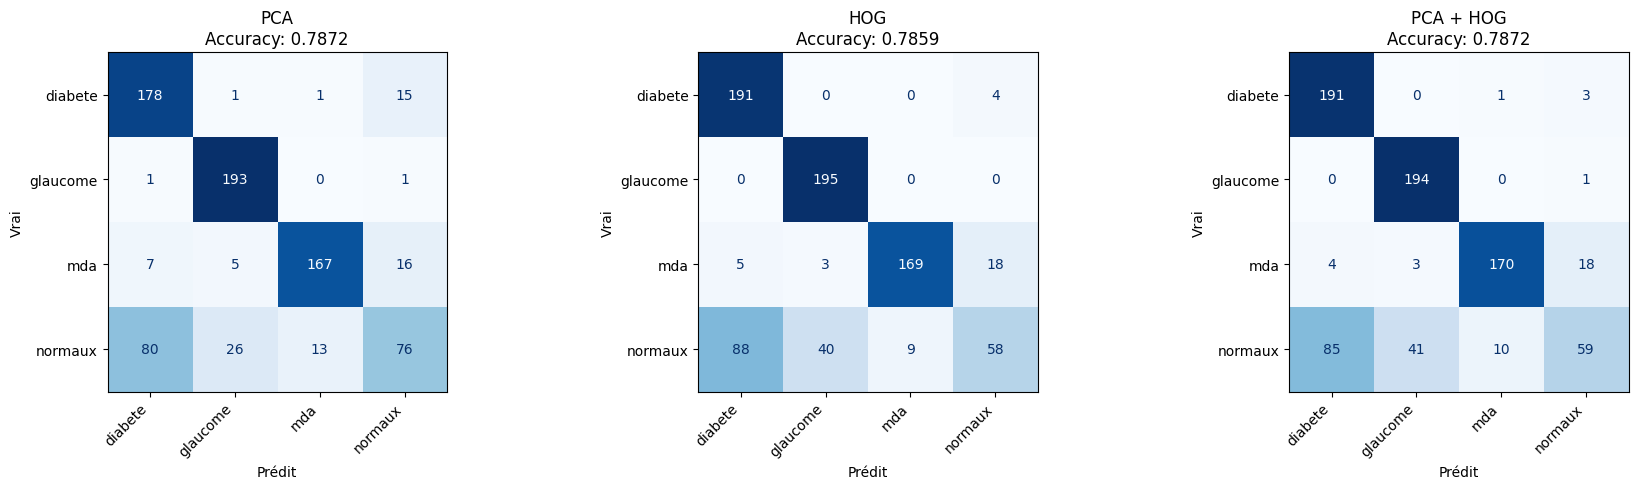

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, data) in enumerate(results.items()):
    y_pred = data['y_pred']
    cm = confusion_matrix(y_test, y_pred, labels=list(range(len(classes))))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=axes[idx], values_format='d', cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{name}\nAccuracy: {data["test_accuracy"]:.4f}')
    axes[idx].set_xlabel('Prédit')
    axes[idx].set_ylabel('Vrai')
    plt.setp(axes[idx].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [15]:
print("\n" + "="*70)
print(f"RAPPORT DÉTAILLÉ POUR LA MEILLEURE APPROCHE: {best_approach}")
print("="*70)

best_data = results[best_approach]
print(f"\nParamètres:")
for param, value in best_data['best_params'].items():
    print(f"  {param}: {value}")

print("\nRapport de classification:")
print(classification_report(y_test, best_data['y_pred'], target_names=classes, zero_division=0))


RAPPORT DÉTAILLÉ POUR LA MEILLEURE APPROCHE: PCA

Paramètres:
  pca__n_components: 100
  rf__n_estimators: 300
  rf__max_depth: 30
  rf__min_samples_split: 2
  rf__min_samples_leaf: 1
  rf__max_features: sqrt
  rf__random_state: 42

Rapport de classification:
              precision    recall  f1-score   support

     diabete       0.67      0.91      0.77       195
    glaucome       0.86      0.99      0.92       195
         mda       0.92      0.86      0.89       195
     normaux       0.70      0.39      0.50       195

    accuracy                           0.79       780
   macro avg       0.79      0.79      0.77       780
weighted avg       0.79      0.79      0.77       780



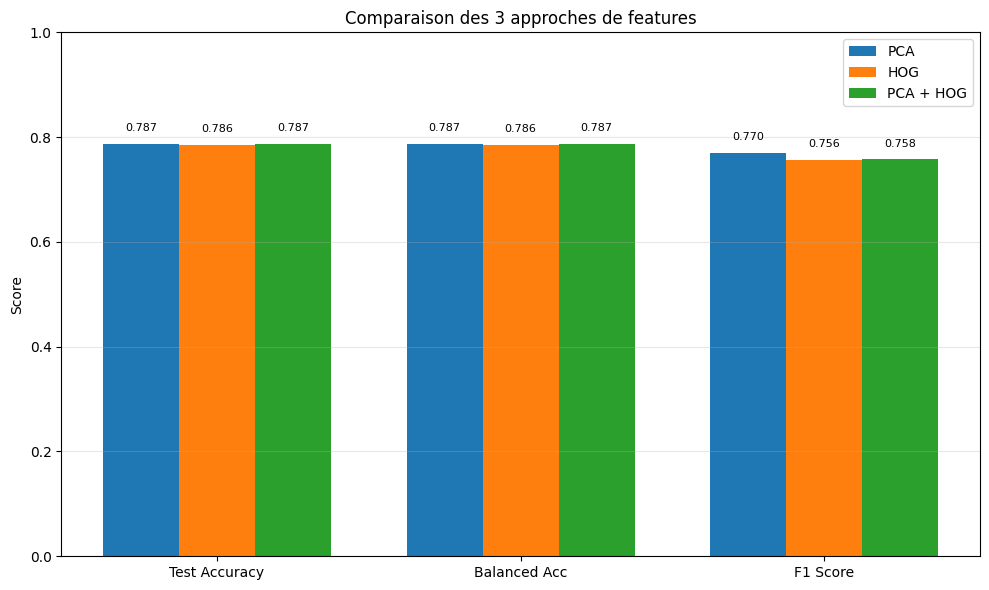

In [16]:
metrics = ['Test Accuracy', 'Balanced Acc', 'F1 Score']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, approach in enumerate(['PCA', 'HOG', 'PCA + HOG']):
    row = comparison_df[comparison_df['Approche'] == approach].iloc[0]
    values = [row['Test Accuracy'], row['Balanced Acc'], row['F1 Score']]
    ax.bar(x + i*width, values, width, label=approach)

ax.set_ylabel('Score')
ax.set_title('Comparaison des 3 approches de features')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

for i, approach in enumerate(['PCA', 'HOG', 'PCA + HOG']):
    row = comparison_df[comparison_df['Approche'] == approach].iloc[0]
    values = [row['Test Accuracy'], row['Balanced Acc'], row['F1 Score']]
    for j, v in enumerate(values):
        ax.text(x[j] + i*width, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Entraînement du meilleur modèle PCA + HOG (sklearn, pour plot_tree)...
Entraînement terminé ✓


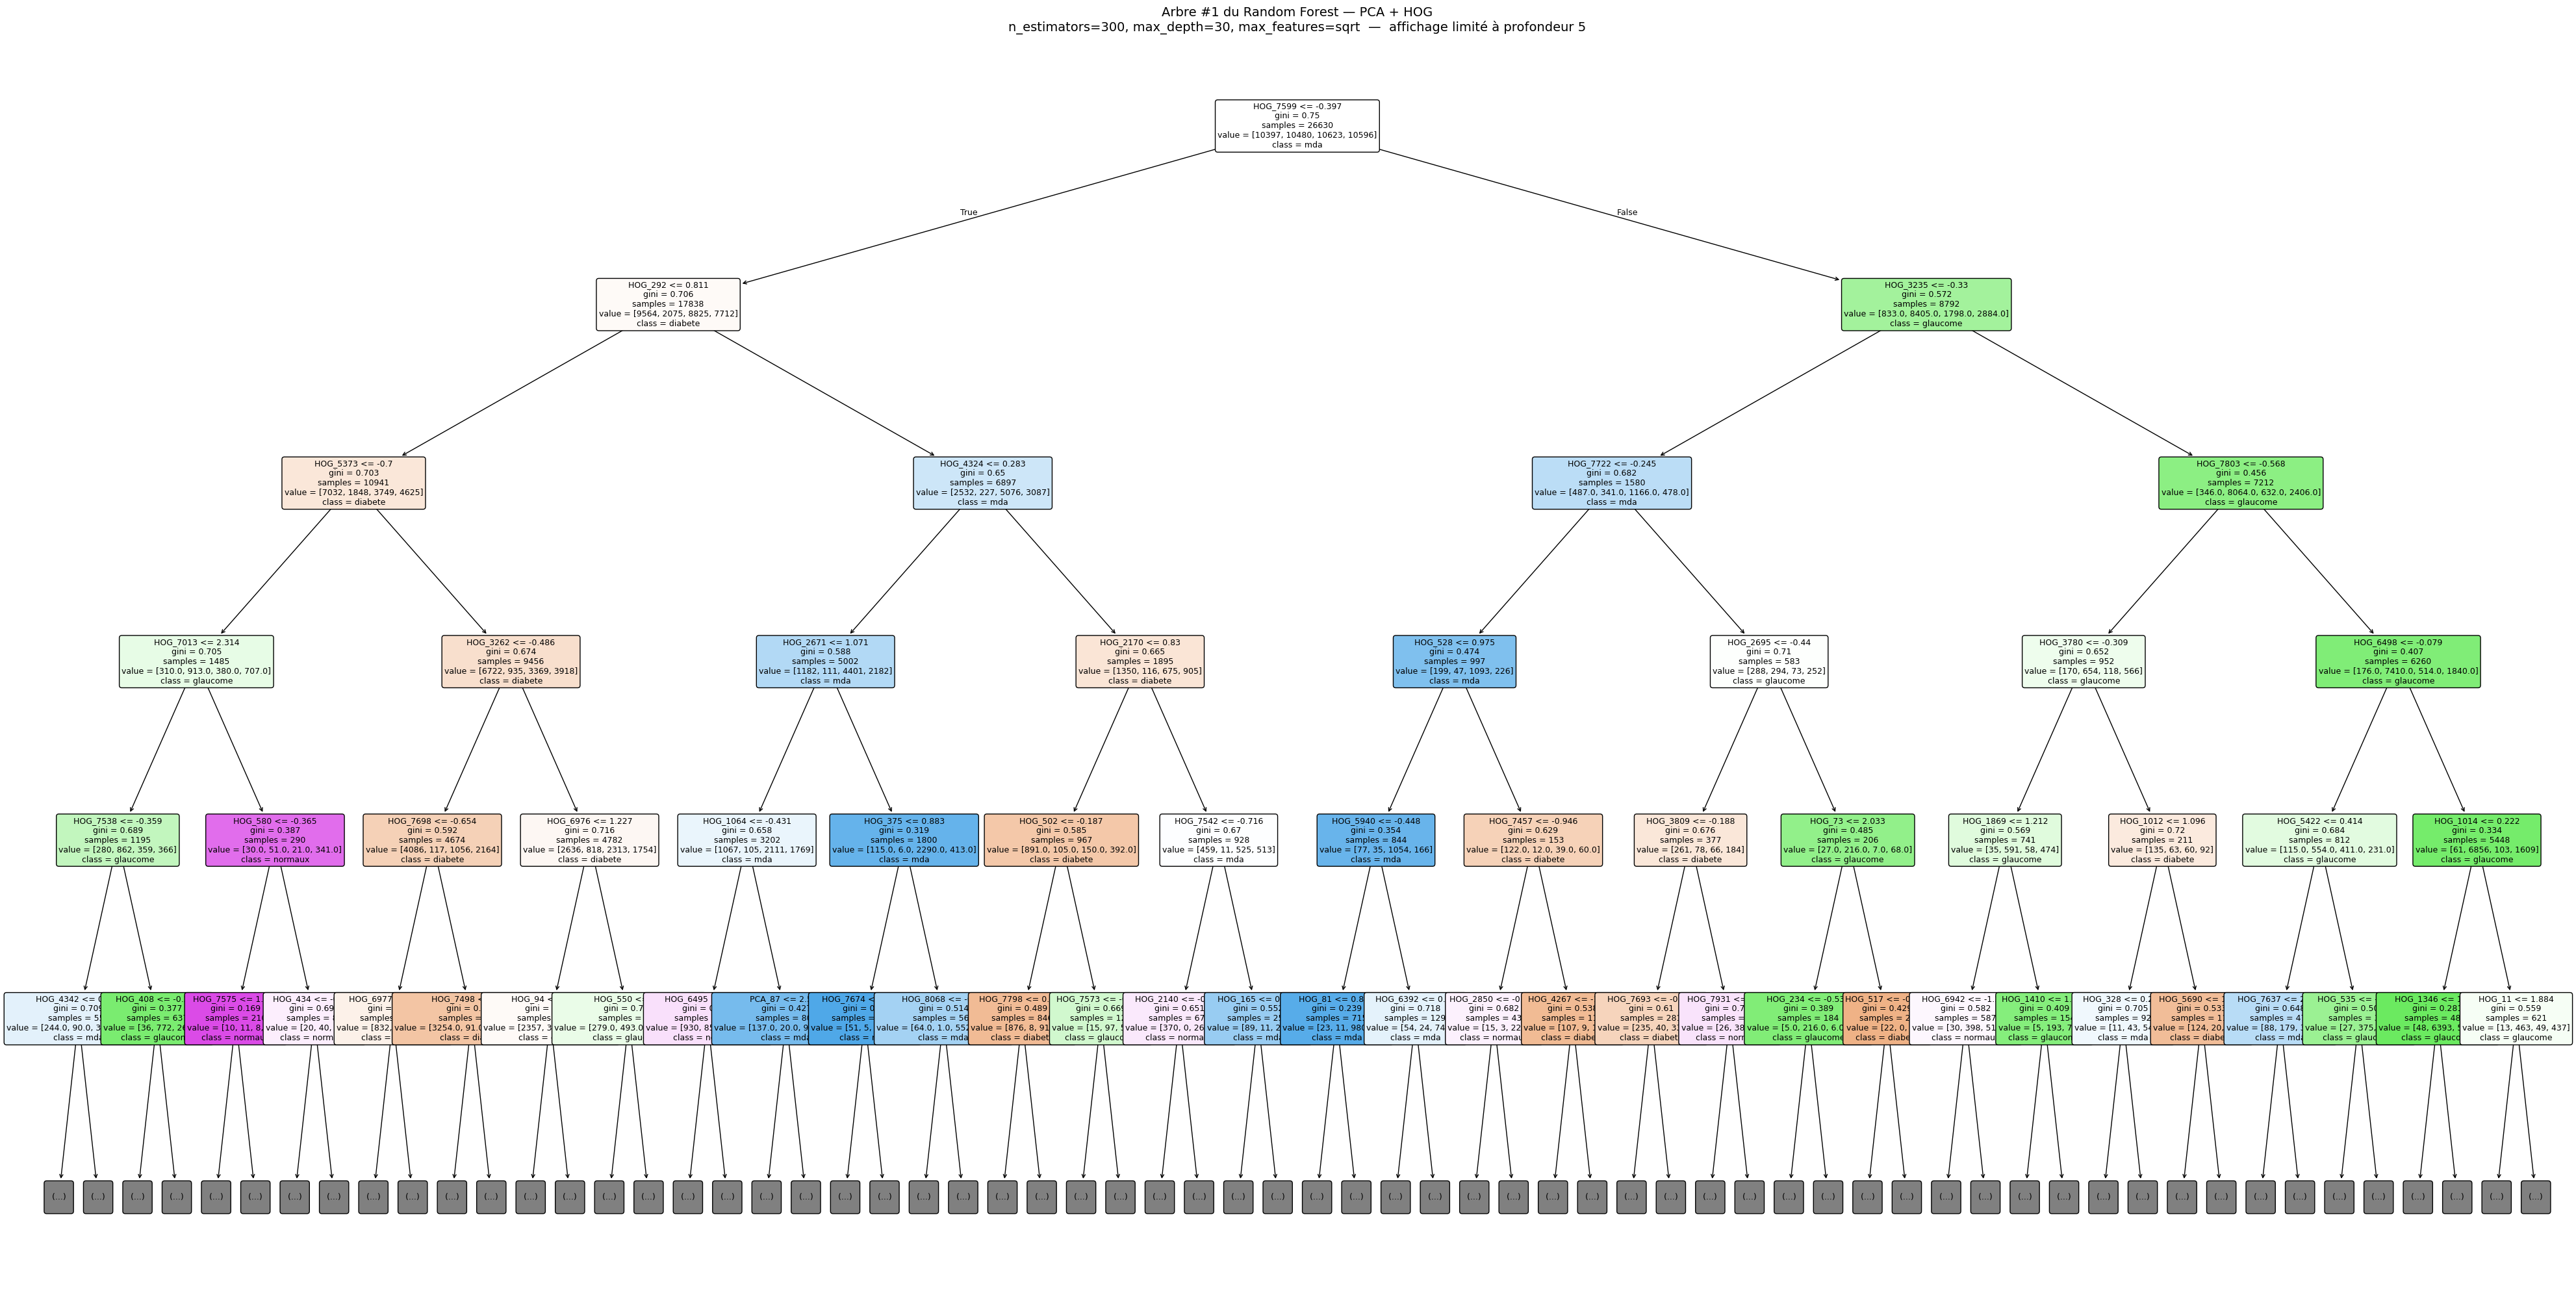

In [17]:
from sklearn.tree import plot_tree
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

BEST_PCA_N = 100
BEST_RF_PARAMS = dict(
    n_estimators=300,
    max_depth=30,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42
)

pixel_cols = list(range(X_train_pixels_scaled.shape[1]))
hog_cols   = list(range(X_train_pixels_scaled.shape[1],
                        X_train_pixels_scaled.shape[1] + X_train_hog_scaled.shape[1]))

X_train_combined_raw = np.hstack([X_train_pixels_scaled, X_train_hog_scaled])

best_pipe = Pipeline([
    ('features', ColumnTransformer([
        ('pca', PCA(n_components=BEST_PCA_N, random_state=42), pixel_cols),
        ('hog', 'passthrough', hog_cols)
    ])),
    ('rf', RandomForestClassifier(**BEST_RF_PARAMS))
])

print("Entraînement du meilleur modèle PCA + HOG (sklearn, pour plot_tree)...")
best_pipe.fit(X_train_combined_raw, y_train)
del X_train_combined_raw
print("Entraînement terminé ✓")

feature_names = (
    [f'PCA_{i}' for i in range(BEST_PCA_N)] +
    [f'HOG_{i}' for i in range(X_train_hog_scaled.shape[1])]
)

classes_list = ['diabete', 'glaucome', 'mda', 'normaux']
tree_to_plot = best_pipe.named_steps['rf'].estimators_[0]

fig, ax = plt.subplots(figsize=(40, 20))
plot_tree(
    tree_to_plot,
    max_depth=5,
    feature_names=feature_names,
    class_names=classes_list,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title(
    f"Arbre #1 du Random Forest — PCA + HOG\n"
    f"n_estimators={BEST_RF_PARAMS['n_estimators']}, max_depth={BEST_RF_PARAMS['max_depth']}, "
    f"max_features={BEST_RF_PARAMS['max_features']}  —  affichage limité à profondeur 5",
    fontsize=14
)
plt.tight_layout()
plt.show()